In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

In [8]:
n_entries2numeric = {
    # "10k": 10_000,
    "1M": 1_000_000,
    "10M": 10_000_000,
    "50M": 50_000_000,
    "100M": 100_000_000
}

df = pd.DataFrame()
for s in range(1,4):
    for i, n_entries in enumerate(["1M", "10M", "50M", "100M"]):
        walltime = np.loadtxt(f"./results/scenario{s}/{n_entries}.csv", delimiter=",", skiprows=1, usecols=2)
        row = {"scenario": [s], "n_entries": [n_entries2numeric[n_entries]], "walltime_mean": [walltime.mean() * 1e-6], "walltime_std": [walltime.std() * 1e-6]}
        df = pd.concat([df, pd.DataFrame(row)])
        
    
df.reset_index(drop=True, inplace=True)
df = df.pivot(index="n_entries", columns="scenario")
df

walltime_mean                     walltime_std                    
scenario              1         2         3            1         2         3
n_entries                                                                   
1000000        0.072917  0.047217  0.042583     0.026081  0.002056  0.000709
10000000       0.295574  0.344461  0.368708     0.003815  0.008763  0.002577
50000000       1.242339  1.645834  1.690881     0.007997  0.010886  0.028013
100000000      2.386196  3.066104  3.273656     0.015801  0.049386  0.015008

In [44]:
df_mean_diff = df.walltime_mean

for col in df_mean_diff.columns:
    df_mean_diff[col] = 1 - (df.walltime_mean[1] / df_mean_diff[col])
    
df_mean_diff

/tmp/ipykernel_351415/2621208243.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mean_diff[col] = 1 - (df.walltime_mean[1] / df_mean_diff[col])


scenario,1,2,3
n_entries,,,
1000000,0.0,-0.544291,-0.712359
10000000,0.0,0.141925,0.198354
50000000,0.0,0.245161,0.265271
100000000,0.0,0.221750,0.271092


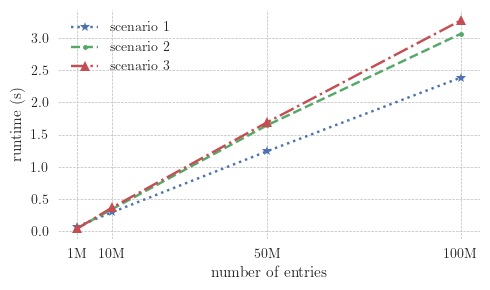

In [19]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.facecolor": "#FFFFFF",
    "axes.grid": True,
    "axes.grid.which": "major",
    "axes.grid.axis": "both",
    "axes.spines.bottom": True,
    "axes.spines.left": True,
    "axes.spines.right": True,
    "axes.spines.top": True,
    "grid.color": "#BBBBBB",
    "grid.linestyle": "--",
    "grid.linewidth": .5,
    "figure.frameon": True
})

fig, ax = plt.subplots(figsize=(5,3))
# ax.set_xscale("log")
ax.set_xticks(df.index, labels=n_entries2numeric.keys())
ax.set_xlabel("number of entries")
ax.set_ylabel("runtime (s)")

linestyles = [":", "--", "-."]
markers = ["*", ".", "^"]
for i, s in enumerate(df.walltime_mean.columns):
    ax.plot(df.walltime_mean[s],
            linestyle=linestyles[i], 
            marker=markers[i]
           )

ax.legend(["scenario 1", "scenario 2", "scenario 3"])

fig.tight_layout()
fig.savefig("plots/runtime_plot.pdf", transparent=True)
fig.savefig("plots/runtime_plot.png", transparent=True)
fig.savefig("plots/runtime_plot.tex", format="pgf", transparent=True)